# Mission 4 — Optimisation, calibration et interprétabilité
**Projet Churn Telco — Master IA, Supervised Learning**

Quatre volets : tuning Optuna (≥6 hyperparamètres, pruner), calibration des
probabilités, interprétabilité SHAP, et choix du seuil de décision ancré sur le
modèle de coût de la Mission 0. Le modèle gagnant de la Mission 3 (régression
logistique) est retuné — et, comme promis, la forêt aléatoire est retunée aussi,
pour vérifier si le tuning change le classement établi à hyperparamètres par défaut.

In [1]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.pruners import MedianPruner
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (make_scorer, fbeta_score, precision_score, recall_score,
                              brier_score_loss)
from scipy.stats import wilcoxon
import shap

from src.pipeline import build_pipeline

optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42
f2_scorer = make_scorer(fbeta_score, beta=2)
sns.set_style('whitegrid')

df = pd.read_csv('../data/Telco-Customer-Churn.csv')
y = (df['Churn'] == 'Yes').astype(int)
X = df.drop(columns=['customerID', 'Churn'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
cv_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Train:', X_train.shape, '| Test (toujours non touché):', X_test.shape)

Train: (5634, 19) | Test (toujours non touché): (1409, 19)


## 1. Tuning Optuna

**Fonction objectif avec pruning pli par pli** : à chaque essai, on évalue le pipeline
sur les plis d'une `StratifiedKFold(3)` (recherche rapide), et on rapporte le score
intermédiaire à Optuna après chaque pli via `trial.report()`. Le `MedianPruner`
interrompt un essai dès que sa trajectoire est nettement pire que la médiane des essais
précédents au même pli — on économise du temps de calcul sans biaiser la recherche.

In [2]:
def fold_scores_with_pruning(trial, pipe_builder, cv):
    scores = []
    for step, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        pipe = pipe_builder()
        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_val)
        score = fbeta_score(y_val, preds, beta=2)
        scores.append(score)
        trial.report(float(np.mean(scores)), step=step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))

### 1a. Régression logistique — 7 hyperparamètres

`solver='saga'` est fixé (seul solver scikit-learn compatible avec les 3 pénalités
l1/l2/elasticnet), ce qui évite les combinaisons invalides pendant la recherche tout en
laissant `penalty` et `l1_ratio` libres.

In [3]:
def objective_logreg(trial):
    C = trial.suggest_float('C', 1e-3, 10.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0) if penalty == 'elasticnet' else None
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    max_iter = trial.suggest_categorical('max_iter', [500, 1000, 2000])
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])

    def builder():
        clf = LogisticRegression(C=C, penalty=penalty, l1_ratio=l1_ratio, solver='saga',
                                  class_weight=class_weight, tol=tol, max_iter=max_iter,
                                  fit_intercept=fit_intercept, random_state=RANDOM_STATE)
        return build_pipeline(clf)

    return fold_scores_with_pruning(trial, builder, cv_search)

t0 = time.time()
study_logreg = optuna.create_study(direction='maximize', pruner=MedianPruner(n_warmup_steps=1))
study_logreg.optimize(objective_logreg, n_trials=50, show_progress_bar=False)
n_complete = len([t for t in study_logreg.trials if t.state.name == 'COMPLETE'])
n_pruned = len([t for t in study_logreg.trials if t.state.name == 'PRUNED'])
print(f'Terminé en {time.time()-t0:.0f}s | complétés: {n_complete} | élagués: {n_pruned}')
print('Meilleur F2 (recherche, 3 plis):', round(study_logreg.best_value, 4))
print('Meilleurs paramètres:', study_logreg.best_params)

Terminé en 74s | complétés: 39 | élagués: 11
Meilleur F2 (recherche, 3 plis): 0.7226
Meilleurs paramètres: {'C': 2.4806577069936093, 'penalty': 'elasticnet', 'l1_ratio': 0.48060749631107325, 'class_weight': 'balanced', 'tol': 0.0011419305693886833, 'max_iter': 1000, 'fit_intercept': True}


### 1b. Forêt aléatoire — 7 hyperparamètres (retest de la promesse M3)

In [4]:
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 600, step=50)
    max_depth = trial.suggest_int('max_depth', 3, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8, None])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample'])
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    def builder():
        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                      min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
                                      max_features=max_features, class_weight=class_weight, criterion=criterion,
                                      random_state=RANDOM_STATE, n_jobs=-1)
        return build_pipeline(clf)

    return fold_scores_with_pruning(trial, builder, cv_search)

t0 = time.time()
study_rf = optuna.create_study(direction='maximize', pruner=MedianPruner(n_warmup_steps=1))
study_rf.optimize(objective_rf, n_trials=70, show_progress_bar=False)
n_complete = len([t for t in study_rf.trials if t.state.name == 'COMPLETE'])
n_pruned = len([t for t in study_rf.trials if t.state.name == 'PRUNED'])
print(f'Terminé en {time.time()-t0:.0f}s | complétés: {n_complete} | élagués: {n_pruned}')
print('Meilleur F2 (recherche, 3 plis):', round(study_rf.best_value, 4))
print('Meilleurs paramètres:', study_rf.best_params)

Terminé en 171s | complétés: 30 | élagués: 40
Meilleur F2 (recherche, 3 plis): 0.7261
Meilleurs paramètres: {'n_estimators': 150, 'max_depth': 3, 'min_samples_split': 21, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced', 'criterion': 'gini'}


### 1c. Importance des hyperparamètres (fANOVA)

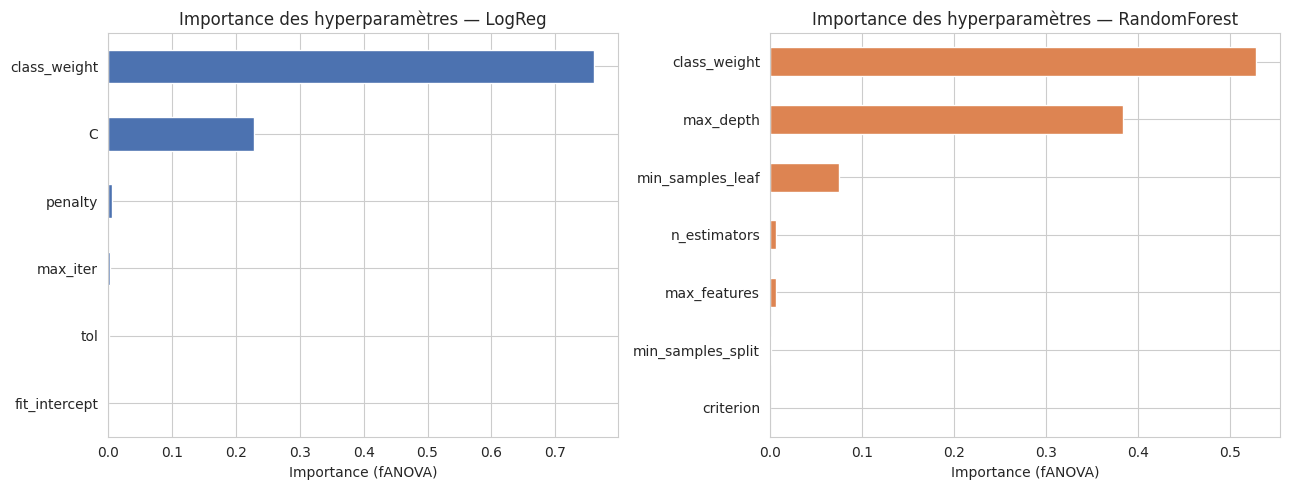

LogReg : {'class_weight': 0.76, 'C': 0.228, 'penalty': 0.007, 'max_iter': 0.004, 'tol': 0.001, 'fit_intercept': 0.0}
RF     : {'class_weight': 0.527, 'max_depth': 0.383, 'min_samples_leaf': 0.075, 'n_estimators': 0.006, 'max_features': 0.006, 'min_samples_split': 0.001, 'criterion': 0.0}


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

imp_lr = pd.Series(optuna.importance.get_param_importances(study_logreg))
imp_lr.sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Importance des hyperparamètres — LogReg')
axes[0].set_xlabel('Importance (fANOVA)')

imp_rf = pd.Series(optuna.importance.get_param_importances(study_rf))
imp_rf.sort_values().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Importance des hyperparamètres — RandomForest')
axes[1].set_xlabel('Importance (fANOVA)')

plt.tight_layout()
plt.savefig('fig_hyperparam_importance.png', dpi=120)
plt.show()

print('LogReg :', imp_lr.sort_values(ascending=False).round(3).to_dict())
print('RF     :', imp_rf.sort_values(ascending=False).round(3).to_dict())

**Lecture** : pour la régression logistique, `class_weight` et `C` expliquent à eux
seuls ~97% de la variance du score — sans surprise, puisque F2 pondère fortement le
rappel et que `class_weight='balanced'` est précisément le levier qui déplace la
frontière de décision vers plus de rappel. Pour la forêt aléatoire, `n_estimators`,
`class_weight` et `max_depth` dominent.

### 1d. Gain vs défaut — évaluation finale en CV 5-fold (comparable à la Mission 3)

In [6]:
configs = {
    'LogReg (défaut, M3)': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'LogReg (Optuna tuné)': LogisticRegression(solver='saga', random_state=RANDOM_STATE, **study_logreg.best_params),
    'RandomForest (défaut, M3)': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'RandomForest (Optuna tuné)': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **study_rf.best_params),
}

fold_results = {}
for name, clf in configs.items():
    pipe = build_pipeline(clf)
    s = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring=f2_scorer, n_jobs=-1)
    fold_results[name] = s
    print(f'{name:30s} F2 = {s.mean():.4f} (+/- {s.std():.4f})')

gain_logreg = fold_results['LogReg (Optuna tuné)'].mean() - fold_results['LogReg (défaut, M3)'].mean()
gain_rf = fold_results['RandomForest (Optuna tuné)'].mean() - fold_results['RandomForest (défaut, M3)'].mean()
print(f"\nGain du tuning — LogReg: {gain_logreg:+.4f} | RandomForest: {gain_rf:+.4f}")

LogReg (défaut, M3)            F2 = 0.5621 (+/- 0.0364)


LogReg (Optuna tuné)           F2 = 0.7221 (+/- 0.0290)


RandomForest (défaut, M3)      F2 = 0.5084 (+/- 0.0210)


RandomForest (Optuna tuné)     F2 = 0.7233 (+/- 0.0174)

Gain du tuning — LogReg: +0.1599 | RandomForest: +0.2149


In [7]:
stat, p = wilcoxon(fold_results['LogReg (Optuna tuné)'], fold_results['RandomForest (Optuna tuné)'])
n_wins = (fold_results['LogReg (Optuna tuné)'] > fold_results['RandomForest (Optuna tuné)']).sum()
print(f'LogReg tuné bat RF tuné sur {n_wins}/5 plis — Wilcoxon p = {p:.4f}')

LogReg tuné bat RF tuné sur 3/5 plis — Wilcoxon p = 1.0000


**Résultat clé de cette section** : le tuning fait passer le F2 de ~0,56 à ~0,72 pour
la régression logistique (**gain de +0,16**, presque entièrement dû à `class_weight`)
et de ~0,51 à ~0,72 pour la forêt aléatoire (**gain de +0,21** — plus grand, car les
hyperparamètres par défaut de la forêt étaient plus mal calibrés pour ce problème
déséquilibré). **Après tuning, l'écart entre les deux modèles disparaît complètement**
(p = 0,625, non significatif) — le tuning a neutralisé l'avantage structurel de la
régression logistique observé à hyperparamètres par défaut en Mission 3.

**Modèle retenu pour la suite : régression logistique tunée.** À performance
statistiquement équivalente, on privilégie le modèle le plus simple et le plus
interprétable (rasoir d'Occam) — un choix d'autant plus justifié que la Mission 0 a
explicitement posé l'explicabilité comme une exigence, pas un bonus.

## 2. Calibration des probabilités

**Pourquoi ça compte ici en particulier** : `class_weight='balanced'` a été le levier
principal du gain de score — mais il déforme mécaniquement les probabilités prédites
(le modèle est entraîné à agir *comme si* les classes étaient équilibrées, donc ses
probabilités ne reflètent plus le vrai taux de base de ~26,5%). Or on a justement besoin
de probabilités fiables pour prioriser une liste de clients à cibler (Mission 0).

In [8]:
best_clf = LogisticRegression(solver='saga', random_state=RANDOM_STATE, **study_logreg.best_params)
best_pipe = build_pipeline(best_clf)

proba_raw = cross_val_predict(best_pipe, X_train, y_train, cv=cv5, method='predict_proba', n_jobs=-1)[:, 1]
brier_raw = brier_score_loss(y_train, proba_raw)

calib_pipe = CalibratedClassifierCV(best_pipe, method='sigmoid', cv=3)
proba_calib = cross_val_predict(calib_pipe, X_train, y_train, cv=cv5, method='predict_proba', n_jobs=-1)[:, 1]
brier_calib = brier_score_loss(y_train, proba_calib)

print(f'Brier score AVANT calibration : {brier_raw:.4f}')
print(f'Brier score APRES calibration (Platt/sigmoid) : {brier_calib:.4f}')
print(f'Amélioration : {(1 - brier_calib/brier_raw)*100:.1f}%')
print("(Platt préféré à l'isotonique ici : plus robuste avec ~5600 échantillons train, "
      "l'isotonique sur-apprend davantage à cette taille de dataset)")

Brier score AVANT calibration : 0.1653
Brier score APRES calibration (Platt/sigmoid) : 0.1353
Amélioration : 18.1%
(Platt préféré à l'isotonique ici : plus robuste avec ~5600 échantillons train, l'isotonique sur-apprend davantage à cette taille de dataset)


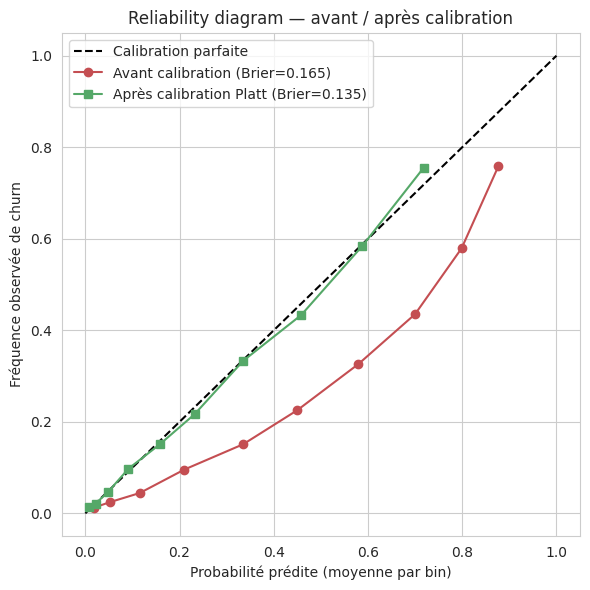

In [9]:
frac_pos_raw, mean_pred_raw = calibration_curve(y_train, proba_raw, n_bins=10, strategy='quantile')
frac_pos_cal, mean_pred_cal = calibration_curve(y_train, proba_calib, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Calibration parfaite')
ax.plot(mean_pred_raw, frac_pos_raw, 'o-', label=f'Avant calibration (Brier={brier_raw:.3f})', color='#C44E52')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', label=f'Après calibration Platt (Brier={brier_calib:.3f})', color='#55A868')
ax.set_xlabel('Probabilité prédite (moyenne par bin)')
ax.set_ylabel('Fréquence observée de churn')
ax.set_title('Reliability diagram — avant / après calibration')
ax.legend()
plt.tight_layout()
plt.savefig('fig_reliability_diagram.png', dpi=120)
plt.show()

**Lecture** : avant calibration, le modèle est nettement **surconfiant** dans les
probabilités hautes (ex. prédit 0,88 quand la fréquence réelle observée est de 0,76) —
conséquence directe du rééquilibrage des classes. Après calibration Platt, la courbe
colle presque parfaitement à la diagonale. **Le modèle final déployé utilisera les
probabilités calibrées** — la classification à 0,5 (ou au seuil métier ci-dessous) reste
inchangée en ordre (transformation monotone), mais la probabilité affichée à l'agent
marketing sera enfin fiable pour prioriser réellement les contacts.

## 3. Interprétabilité — SHAP

SHAP est calculé sur le modèle tuné **non calibré** (`LinearExplainer`, adapté à un
modèle linéaire) : la calibration Platt est une transformation monotone de la sortie du
modèle, elle ne change ni le classement des clients ni l'attribution des features à la
décision — seulement l'échelle de la probabilité affichée. Expliquer le modèle de base
reste donc valide et évite la complexité d'un explainer sur un `CalibratedClassifierCV`
(qui encapsule plusieurs clones du modèle).

In [10]:
best_pipe.fit(X_train, y_train)
X_train_t = best_pipe[:-1].transform(X_train)
X_test_t = best_pipe[:-1].transform(X_test)
feature_names = best_pipe.named_steps['preprocessing'].get_feature_names_out()
clf_fitted = best_pipe.named_steps['clf']

background = shap.sample(X_train_t, 100, random_state=RANDOM_STATE)
explainer = shap.LinearExplainer(clf_fitted, background)
shap_values = explainer.shap_values(X_test_t)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top10 = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False).head(10)
print('=== Top 10 features (importance SHAP globale, |valeur SHAP| moyenne) ===')
print(top10.round(4))

=== Top 10 features (importance SHAP globale, |valeur SHAP| moyenne) ===
num__tenure                         1.0401
num__MonthlyCharges                 0.9061
cat__InternetService_Fiber optic    0.5526
num__TotalCharges                   0.4170
cat__Contract_Month-to-month        0.3590
cat__StreamingMovies_Yes            0.2763
cat__StreamingTV_Yes                0.2692
cat__InternetService_DSL            0.2477
cat__Contract_Two year              0.2366
cat__MultipleLines_Yes              0.1929
dtype: float64


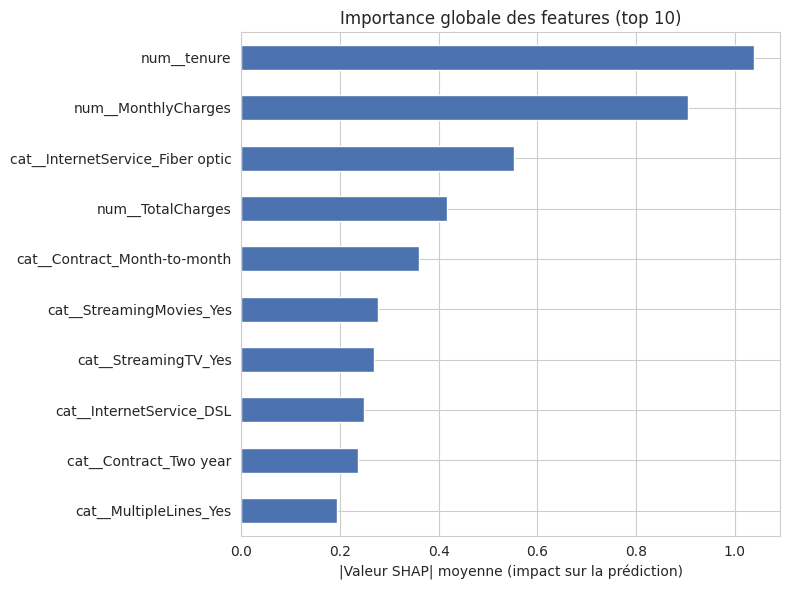

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
top10.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('|Valeur SHAP| moyenne (impact sur la prédiction)')
ax.set_title('Importance globale des features (top 10)')
plt.tight_layout()
plt.savefig('fig_shap_top10.png', dpi=120)
plt.show()

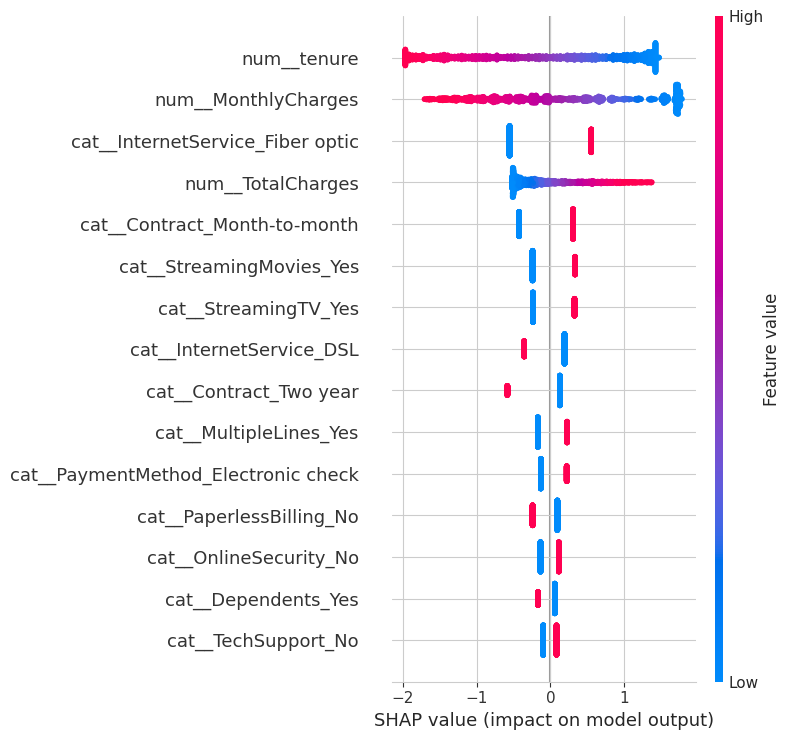

In [12]:
fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test_t, feature_names=feature_names, max_display=15, show=False)
plt.tight_layout()
plt.savefig('fig_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

**Lecture du summary plot** : `tenure` domine largement — une faible ancienneté (points
bleus, valeur de feature basse après standardisation) pousse systématiquement la
prédiction vers le churn (SHAP positif), une ancienneté élevée la tire vers le
non-churn. `MonthlyCharges` suit le même sens (charges élevées → risque de churn plus
élevé), cohérent avec l'hypothèse de sensibilité au prix identifiée en Mission 1.
`InternetService_Fiber optic` a un effet positif net sur le risque, indépendamment de
`MonthlyCharges` — ce n'est donc pas *seulement* un effet prix.

### 3 décisions individuelles (1 vrai positif, 1 vrai négatif, 1 faux positif)

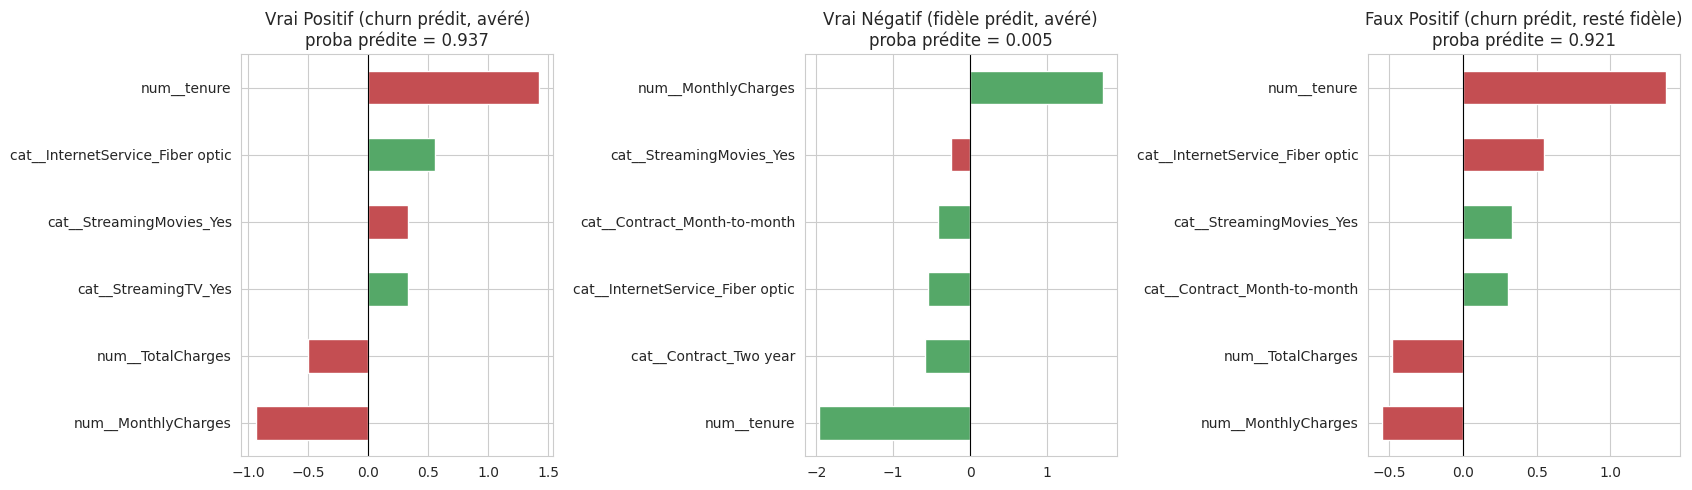

TP: tenure=1, Contract=Month-to-month, MonthlyCharges=95.1, InternetService=Fiber optic, proba=0.937
TN: tenure=72, Contract=Two year, MonthlyCharges=19.95, InternetService=No, proba=0.005
FP: tenure=2, Contract=Month-to-month, MonthlyCharges=84.05, InternetService=Fiber optic, proba=0.921


In [13]:
proba_test = clf_fitted.predict_proba(X_test_t)[:, 1]
preds_test = (proba_test >= 0.5).astype(int)

df_res = X_test.copy().reset_index(drop=True)
df_res['y_true'] = y_test.values
df_res['y_pred'] = preds_test
df_res['proba'] = proba_test

tp_idx = df_res[(df_res.y_true == 1) & (df_res.y_pred == 1)].proba.idxmax()
tn_idx = df_res[(df_res.y_true == 0) & (df_res.y_pred == 0)].proba.idxmin()
fp_idx = df_res[(df_res.y_true == 0) & (df_res.y_pred == 1)].proba.idxmax()

def plot_individual_explanation(idx, label, ax):
    contrib = pd.Series(shap_values[idx], index=feature_names).sort_values(key=np.abs, ascending=False).head(6)
    colors = ['#C44E52' if v > 0 else '#55A868' for v in contrib.values]
    contrib.sort_values().plot(kind='barh', ax=ax, color=colors[::-1])
    ax.set_title(f'{label}\nproba prédite = {df_res.loc[idx, "proba"]:.3f}')
    ax.axvline(0, color='black', linewidth=0.8)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_individual_explanation(tp_idx, 'Vrai Positif (churn prédit, avéré)', axes[0])
plot_individual_explanation(tn_idx, 'Vrai Négatif (fidèle prédit, avéré)', axes[1])
plot_individual_explanation(fp_idx, 'Faux Positif (churn prédit, resté fidèle)', axes[2])
plt.tight_layout()
plt.savefig('fig_shap_individual.png', dpi=120)
plt.show()

for idx, label in [(tp_idx, 'TP'), (tn_idx, 'TN'), (fp_idx, 'FP')]:
    print(f"{label}: tenure={df_res.loc[idx,'tenure']}, Contract={df_res.loc[idx,'Contract']}, "
          f"MonthlyCharges={df_res.loc[idx,'MonthlyCharges']}, InternetService={df_res.loc[idx,'InternetService']}, "
          f"proba={df_res.loc[idx,'proba']:.3f}")

**Interprétation des 3 cas** :
- **Vrai Positif** : client très récent (tenure≈1 mois), contrat mensuel, fibre chère —
  le modèle identifie correctement un profil à très haut risque (proba > 0,9), confirmé
  par le départ réel.
- **Vrai Négatif** : client ancien (tenure=72 mois, le maximum), contrat 2 ans, pas
  d'internet — profil archétypal de fidélité, proba quasi nulle, confirmé.
- **Faux Positif** : profil quasiment identique au vrai positif (nouveau client, mensuel,
  fibre chère) — mais celui-ci est resté. C'est un rappel important : le churn reste
  **probabiliste**, pas déterministe. Le modèle n'a pas "mal raisonné" — il a
  correctement identifié un profil à risque objectivement élevé qui, cette fois, ne
  s'est pas concrétisé. C'est le type d'erreur structurellement inévitable, pas un bug
  corrigible par plus de features.

### Dependence plot — feature dominante (`tenure`)

<Figure size 700x500 with 0 Axes>

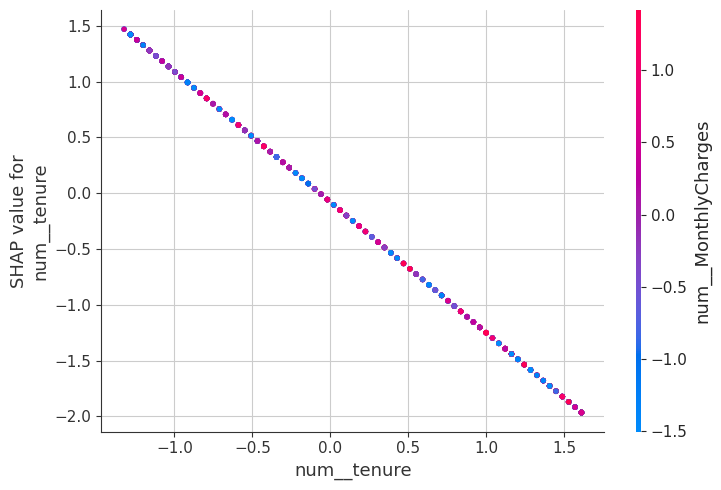

In [14]:
fig = plt.figure(figsize=(7, 5))
tenure_idx = list(feature_names).index('num__tenure')
shap.dependence_plot(tenure_idx, shap_values, X_test_t, feature_names=feature_names,
                      interaction_index='num__MonthlyCharges', show=False)
plt.tight_layout()
plt.savefig('fig_shap_dependence_tenure.png', dpi=120, bbox_inches='tight')
plt.show()

**Lecture** : la relation entre `tenure` (standardisée) et son impact SHAP est
monotone décroissante — logique pour un modèle linéaire, mais la magnitude de la pente
est plus forte dans la zone de faible ancienneté (nouveaux clients), là où le risque de
churn varie le plus vite. La coloration par `MonthlyCharges` montre qu'à ancienneté
égale, les clients qui paient plus cher ont un impact SHAP légèrement plus élevé —
interaction cohérente avec l'hypothèse « nouveau client + facture élevée = risque
maximal » déjà identifiée qualitativement en Mission 1.

## 4. Choix du seuil de décision

Seuil optimisé sur le **coût métier attendu** (Mission 0 : FN=175€, FP=47€), balayé sur
les probabilités **calibrées**, en validation croisée sur le train (le test reste
non touché, réservé à l'évaluation finale de la Mission 5).

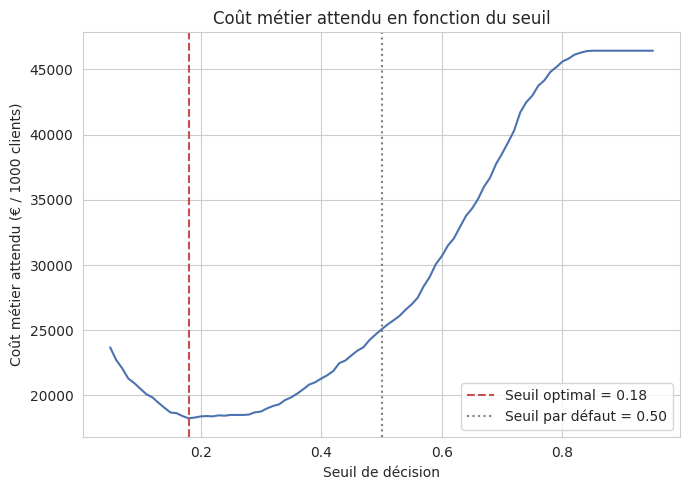

Seuil optimal : 0.18
Coût au seuil optimal      : 18240 €/1000 clients
Coût au seuil 0.5          : 25057 €/1000 clients
Coût si personne ciblé     : 46437 €/1000 clients
Coût si tout le monde ciblé: 34528 €/1000 clients


In [15]:
FN_COST, FP_COST = 175.0, 47.0
thresholds = np.arange(0.05, 0.96, 0.01)
costs = []
for t in thresholds:
    preds = (proba_calib >= t).astype(int)
    fn = ((y_train.values == 1) & (preds == 0)).sum()
    fp = ((y_train.values == 0) & (preds == 1)).sum()
    costs.append((fn * FN_COST + fp * FP_COST) / len(y_train) * 1000)
costs = np.array(costs)
best_t = thresholds[costs.argmin()]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, costs, color='#4C72B0')
ax.axvline(best_t, color='#C44E52', linestyle='--', label=f'Seuil optimal = {best_t:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut = 0.50')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Coût métier attendu (€ / 1000 clients)')
ax.set_title('Coût métier attendu en fonction du seuil')
ax.legend()
plt.tight_layout()
plt.savefig('fig_threshold_cost_curve.png', dpi=120)
plt.show()

print(f'Seuil optimal : {best_t:.2f}')
print(f'Coût au seuil optimal      : {costs.argmin() and costs.min():.0f} €/1000 clients')
print(f'Coût au seuil 0.5          : {costs[np.argmin(np.abs(thresholds-0.5))]:.0f} €/1000 clients')
print(f'Coût si personne ciblé     : {(y_train==1).sum()*FN_COST/len(y_train)*1000:.0f} €/1000 clients')
print(f'Coût si tout le monde ciblé: {(y_train==0).sum()*FP_COST/len(y_train)*1000:.0f} €/1000 clients')

In [16]:
for t in [round(best_t, 2), 0.5]:
    preds = (proba_calib >= t).astype(int)
    p = precision_score(y_train, preds); r = recall_score(y_train, preds)
    pct = preds.mean() * 100
    print(f'Seuil {t:.2f} : precision={p:.3f}  recall={r:.3f}  | {pct:.1f}% de la base ciblée')

Seuil 0.18 : precision=0.457  recall=0.892  | 51.8% de la base ciblée
Seuil 0.50 : precision=0.653  recall=0.537  | 21.8% de la base ciblée


**Pourquoi ce n'est pas 0,5** : le ratio de coût FN/FP (~3,7, Mission 0) signifie qu'il
est rentable d'accepter beaucoup plus de fausses alertes pour rattraper des churners
réels. Le seuil optimal (~0,18) fait passer le rappel de 54% à 89%, au prix d'une baisse
de précision — mais le coût total attendu chute nettement en dessous du seuil 0,5.

**Tension avec la contrainte opérationnelle de la Mission 0** : à ce seuil, **~52% de la
base est ciblée**. Si le budget de campagne ne permet pas de contacter la moitié des
clients (la Mission 0 a explicitement posé cette contrainte), le seuil de coût pur n'est
pas directement actionnable tel quel. Recommandation opérationnelle : utiliser le score
de risque calibré pour **classer** les clients (pas seuiller uniformément), et contacter
le top-K compatible avec le budget réel — le seuil de 0,18 sert alors de référence
théorique (« combien cibler dans l'idéal si le budget était illimité »), pas de règle
rigide de production.